In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("PipeTobacco.csv")

# Preview data
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.359163e+09,290,i.imgur.com,17ahvt,Pipe shape chart,FantasticMrToad,312,22,24,http://www.reddit.com/r/PipeTobacco/comments/1...,NaN,NaN,False,http://c.thumbs.redditmedia.com/5zWXuiI7l2B0-7...,t5_2rbzz,False,NaN,NaN,False,t3_17ahvt,http://i.imgur.com/WSdbzsi.jpg,NaN
1,1.354311e+09,276,self.PipeTobacco,142kye,"Guys, let's be serious for a minute. I think w...",fancyPantsOne,328,52,137,http://www.reddit.com/r/PipeTobacco/comments/1...,"I don't mean to bring everybody down, but I fe...",NaN,False,self,t5_2rbzz,False,NaN,NaN,True,t3_142kye,http://www.reddit.com/r/PipeTobacco/comments/1...,NaN
2,1.358454e+09,222,i.imgur.com,16rr8l,TIL Disney used to sell tobacco. The Disneylan...,HEXAEMERON,233,11,32,http://www.reddit.com/r/PipeTobacco/comments/1...,NaN,NaN,False,http://a.thumbs.redditmedia.com/x1Sg6AH37baeiV...,t5_2rbzz,False,NaN,past,False,t3_16rr8l,http://i.imgur.com/2d7iO.jpg,NaN
3,1.352139e+09,210,i.imgur.com,12of99,This is how you smoke a pipe. [X-Post r/pics],meridiem,236,26,23,http://www.reddit.com/r/PipeTobacco/comments/1...,NaN,NaN,False,http://a.thumbs.redditmedia.com/K1TYP0XvSgK-Ra...,t5_2rbzz,False,NaN,NaN,False,t3_12of99,http://i.imgur.com/QVjL7.jpeg,NaN
4,1.356632e+09,171,i.imgur.com,15j0p8,My dad started making his own pipes. What do y...,rukuz,186,15,24,http://www.reddit.com/r/PipeTobacco/comments/1...,NaN,NaN,False,http://d.thumbs.redditmedia.com/mtpcebv7V29pM7...,t5_2rbzz,False,NaN,NaN,False,t3_15j0p8,http://i.imgur.com/Sudvg.jpg,NaN


In [3]:
# Check structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  971 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                81 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

In [4]:
# Check missing values
df.isnull().sum()

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      29
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   919
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class     906
is_self                      0
name                         0
url                          0
distinguished              993
dtype: int64

In [6]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Ensure numeric before taking mean
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mean())

In [8]:
for col in df.columns:
    print(repr(col))

'created_utc'
'score'
'domain'
'id'
'title'
'author'
'ups'
'downs'
'num_comments'
'permalink'
'selftext'
'link_flair_text'
'over_18'
'thumbnail'
'subreddit_id'
'edited'
'link_flair_css_class'
'author_flair_css_class'
'is_self'
'name'
'url'
'distinguished'


In [11]:
hasattr(dt_model, "tree_")

False

In [16]:
print(df.head())
print(df.columns)

    created_utc  score  domain        id  ...  is_self  name  url  distinguished
0  1.359163e+09    290     NaN  133146.5  ...    False   NaN  NaN            NaN
1  1.354311e+09    276     NaN  133146.5  ...     True   NaN  NaN            NaN
2  1.358454e+09    222     NaN  133146.5  ...    False   NaN  NaN            NaN
3  1.352139e+09    210     NaN  133146.5  ...    False   NaN  NaN            NaN
4  1.356632e+09    171     NaN  133146.5  ...    False   NaN  NaN            NaN

[5 rows x 22 columns]
Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [19]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

In [26]:
print("target" in df.columns)

False


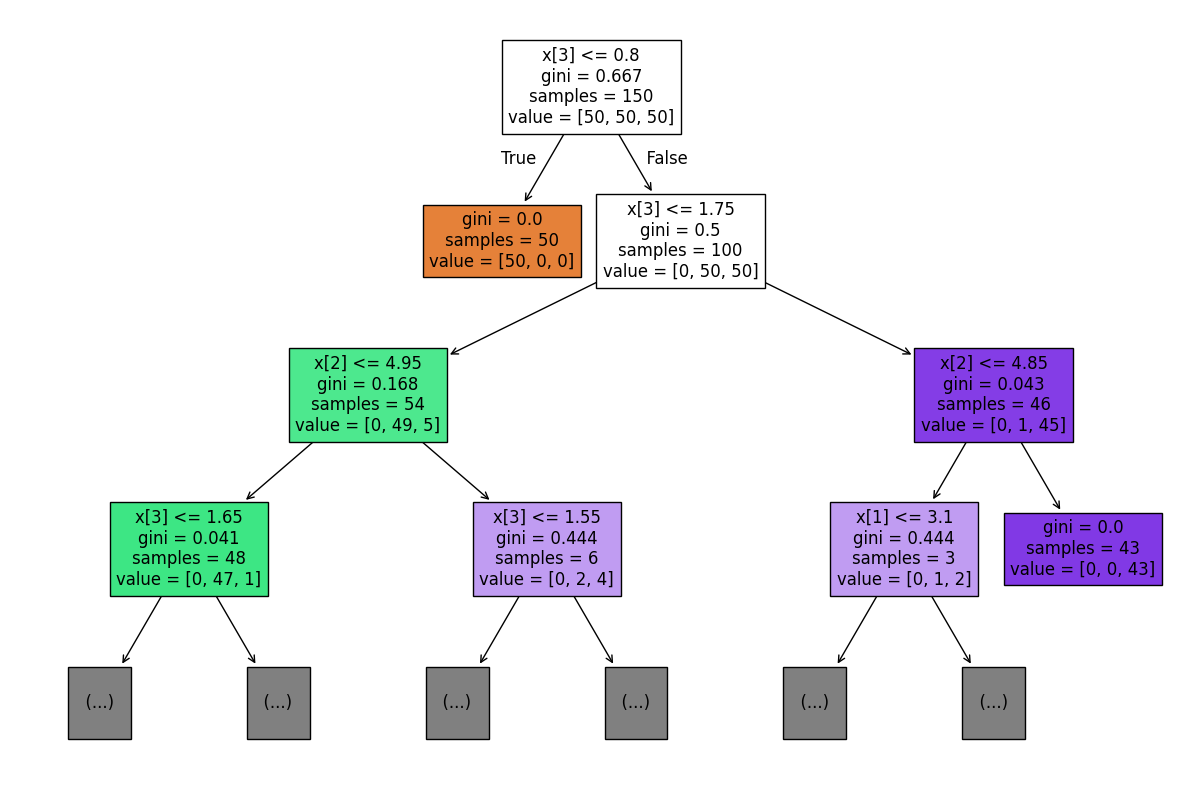

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Create model
dt_model = DecisionTreeClassifier()

# 2. Train model
dt_model.fit(X, y)

# 3. Plot tree
plt.figure(figsize=(15,10))
plot_tree(dt_model, filled=True, max_depth=3)
plt.show()

In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load sample data
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)

# Train
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [35]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



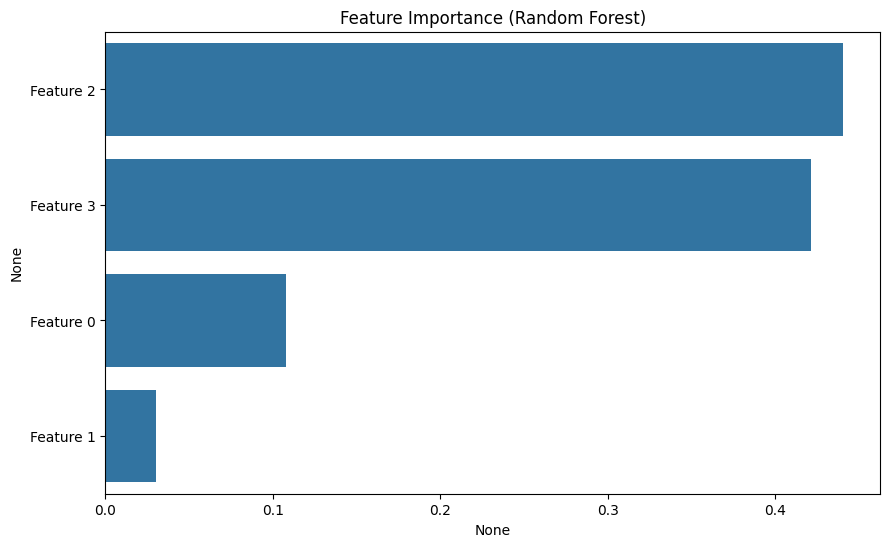

In [37]:
importances = rf_model.feature_importances_

features = [f"Feature {i}" for i in range(X.shape[1])]  # fallback

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importance (Random Forest)")
plt.show()